# EDA — Logic_Based_Educational_Queries

**Dataset:** EXACT 2026 Type 1 (logic / FOL)  
**Plan:** [`PLAN_EDA_Logic.md`](PLAN_EDA_Logic.md)  
**Benchmark BTC (slide 17):** 411 record · 808 câu · ~1.97 câu/mẫu · ~10.8 NL premise/mẫu

In [271]:
from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

ROOT = Path(".").resolve()
DATA_PATH = ROOT.parent / "Exact_2026_Laplace-s_Red_Devils" / "app" / "data" / "raw" / "Logic_Based_Educational_Queries.json"
FIG_DIR = ROOT / "figures"
OUT_DIR = ROOT / "output"
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

BTC = {
    "n_records": 411,
    "n_questions": 808,
    "q_per_record": 1.97,
    "nl_per_record": 10.8,
    "mcq": 358,
    "yn_uncertain": 216,
    "open": 234,
    "fol_pct": 99,
}

print(f"Data: {DATA_PATH}")
print(f"Exists: {DATA_PATH.exists()}")


Data: E:\exact_2026\Exact_2026_Laplace-s_Red_Devils\app\data\raw\Logic_Based_Educational_Queries.json
Exists: True


In [272]:
# --- Helpers: biểu đồ cho thống kê % / phân bố ---
PALETTE = sns.color_palette("muted")


def plot_pct_bars(metrics: dict[str, float], title: str, filename: str, figsize=None) -> None:
    """Bar chart ngang: mỗi metric là % (0–100)."""
    if figsize is None:
        figsize = (9, max(3, len(metrics) * 0.55))
    labels = list(metrics.keys())
    values = list(metrics.values())
    # barh: đảo để mục đầu dict nằm trên cùng biểu đồ
    labels = labels[::-1]
    values = values[::-1]
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(labels, values, color=PALETTE[0], edgecolor="white")
    ax.set_xlim(0, min(105, max(values) * 1.25 + 5 if values else 100))
    ax.set_xlabel("%")
    ax.set_title(title)
    for bar, v in zip(bars, values):
        ax.text(v + 0.8, bar.get_y() + bar.get_height() / 2, f"{v:.1f}%", va="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
    plt.show()


def plot_count_dist(
    series: pd.Series,
    title: str,
    filename: str,
    top_n: int | None = 15,
    horizontal: bool = True,
    *,
    preaggregated: bool = False,
) -> None:
    """Phân bố đếm. preaggregated=True: index=nhãn, value=đã đếm sẵn (không gọi value_counts)."""
    if preaggregated:
        vc = series.sort_values(ascending=True)
        if top_n:
            vc = vc.tail(top_n)
        total = float(vc.sum()) or 1.0
    else:
        vc = series.value_counts()
        if top_n:
            vc = vc.head(top_n)
        total = len(series)
    fig, ax = plt.subplots(figsize=(10, max(4, len(vc) * 0.35)))
    plot_fn = vc.plot.barh if horizontal else vc.plot.bar
    plot_fn(ax=ax, color=PALETTE[1], edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Số lượng")
    for i, (idx, v) in enumerate(vc.items()):
        pct = 100 * v / total
        if horizontal:
            ax.text(v + max(vc) * 0.01, i, f" {v} ({pct:.1f}%)", va="center", fontsize=9)
        else:
            ax.text(i, v, f"{v}\n({pct:.1f}%)", ha="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
    plt.show()


def plot_binary_pie(yes_pct: float, title: str, filename: str, yes_label: str = "Có", no_label: str = "Không") -> None:
    """Pie chart cho 1 tỷ lệ % (có/không)."""
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie(
        [yes_pct, 100 - yes_pct],
        labels=[f"{yes_label}\n{yes_pct:.1f}%", f"{no_label}\n{100-yes_pct:.1f}%"],
        autopct="",
        colors=[PALETTE[2], "#E0E0E0"],
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.2},
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
    plt.show()


def plot_heatmap_ct(ct: pd.DataFrame, title: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax, linewidths=0.5)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
    plt.show()


## 1. Load & flatten


In [273]:
with open(DATA_PATH, encoding="utf-8") as f:
    records = json.load(f)

print(f"Số record: {len(records)}  [BTC: {BTC['n_records']}]")

missing_fol_ids = [rid for rid, r in enumerate(records) if "premises-FOL" not in r]
if missing_fol_ids:
    print(f"⚠ {len(missing_fol_ids)} mẫu thiếu premises-FOL (chỉ có NL): {missing_fol_ids}")


def get_fol(rec: dict) -> list[str]:
    """Một số record không có FOL — trả list rỗng thay vì KeyError."""
    return rec.get("premises-FOL", [])


def normalize_idx(idx: list, n_questions: int) -> list[list]:
    """Chuẩn hóa idx: [[1],[2,3]] hoặc flat [1,2,3] khi chỉ 1 câu (record 132, 133)."""
    if not idx:
        return [[] for _ in range(n_questions)]
    if all(isinstance(x, int) for x in idx):
        return [list(idx)] if n_questions == 1 else [list(idx)] * n_questions
    return idx


def flatten_records(recs: list[dict]) -> pd.DataFrame:
    rows = []
    for rid, rec in enumerate(recs):
        n_prem = len(rec["premises-NL"])
        fol_list = get_fol(rec)
        n_fol = len(fol_list)
        idx_lists = normalize_idx(rec["idx"], len(rec["questions"]))
        for qi, (q, a, exp, idx_used) in enumerate(
            zip(rec["questions"], rec["answers"], rec["explanation"], idx_lists)
        ):
            rows.append(
                {
                    "record_id": rid,
                    "q_idx": qi,
                    "n_premises_nl": n_prem,
                    "n_premises_fol": n_fol,
                    "n_premises_used": len(idx_used),
                    "premise_use_ratio": len(idx_used) / n_prem if n_prem else np.nan,
                    "idx_used": idx_used,
                    "question": q,
                    "answer": a,
                    "explanation": exp,
                    "premises_nl": rec["premises-NL"],
                    "premises_fol": fol_list,
                }
            )
    return pd.DataFrame(rows)


df_q = flatten_records(records)
print(f"Tổng câu flatten: {len(df_q)}  [BTC: {BTC['n_questions']}]")


def row_to_record_dict(row) -> dict:
    """1 câu trong df_q → dict cùng thứ tự / tên field như JSON gốc."""
    return {
        "idx": [list(row["idx_used"])],
        "premises-FOL": list(row["premises_fol"]),
        "premises-NL": list(row["premises_nl"]),
        "questions": [row["question"]],
        "answers": [row["answer"]],
        "explanation": [row["explanation"]],
    }


df_q.head(2)


Số record: 411  [BTC: 411]
⚠ 2 mẫu thiếu premises-FOL (chỉ có NL): [23, 53]
Tổng câu flatten: 808  [BTC: 808]


,record_id,q_idx,n_premises_nl,n_premises_fol,n_premises_used,premise_use_ratio,idx_used,question,answer,explanation,premises_nl,premises_fol
0,0,0,14,14,1,0.071429,[1],Which conclusion follows with the fewest premi...,Unknown,Premise 1 states that if a Python project is w...,"[If a Python code is well-tested, then the pro...","[∀x (WT(x) → O(x)), ∀x (¬PEP8(x) → ¬WT(x)), ∀x..."
1,0,1,14,14,2,0.142857,"[7, 10]",Does it follow that if all Python projects are...,Yes,Premise 10 confirms all Python projects are we...,"[If a Python code is well-tested, then the pro...","[∀x (WT(x) → O(x)), ∀x (¬PEP8(x) → ¬WT(x)), ∀x..."


In [274]:
len(df_q['premises_fol'])


808

In [275]:
# Các câu thuộc mẫu không có premises-FOL — in dạng JSON (như file gốc)
for i in range(len(df_q)):
    if len(df_q["premises_fol"].iloc[i]) == 0:
        print(json.dumps(row_to_record_dict(df_q.iloc[i]), ensure_ascii=False, indent=2))
        print("-" * 60)


{
  "idx": [
    [
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      13
    ]
  ],
  "premises-FOL": [],
  "premises-NL": [
    "A student who understands wave-particle duality can grasp the principle of quantum superposition.",
    "Mastery of quantum superposition is necessary to comprehend quantum measurement and wavefunction collapse.",
    "A deep understanding of wavefunction collapse enables a student to critique interpretations of quantum mechanics.",
    "Critiquing quantum interpretations requires familiarity with Schrödinger's equation and its implications.",
    "A student proficient in Schrödinger's equation can solve problems in quantum tunneling.",
    "Successful application of quantum tunneling concepts allows engagement with quantum computing fundamentals.",
    "A student engaging with quantum computing will explore qubit manipulation and entanglement.",
    "A solid grasp of entanglement is required to analyze

In [276]:
df_rec = pd.DataFrame(
    {
        "record_id": range(len(records)),
        "questions_per_record": [len(r["questions"]) for r in records],
        "n_premises_nl": [len(r["premises-NL"]) for r in records],
        "n_premises_fol": [len(get_fol(r)) for r in records],
        "nl_fol_match": [
            len(r["premises-NL"]) == len(get_fol(r)) for r in records
        ],
        "has_fol": [len(get_fol(r)) > 0 for r in records],
    }
)
df_rec.head()


,record_id,questions_per_record,n_premises_nl,n_premises_fol,nl_fol_match,has_fol
0,0,2,14,14,True,True
1,1,2,11,11,True,True
2,2,2,11,11,True,True
3,3,2,7,7,True,True
4,4,2,8,8,True,True


## 2. Số câu hỏi / 1 mẫu


In [277]:
qpc = df_rec["questions_per_record"]

print("=== questions_per_record ===")
print(qpc.describe())
print(f"Mode: {qpc.mode().iloc[0]} câu/mẫu (xuất hiện {qpc.value_counts().iloc[0]} lần)")

total_questions = int(qpc.sum())
print(f"Tổng câu (sum): {total_questions}  |  BTC: {BTC['n_questions']}  |  Khớp: {total_questions == BTC['n_questions']}")

outlier_rid = int(qpc.idxmax())
print(f"Outlier: record_id={outlier_rid}, questions={qpc.max()}")

print("\n=== Histogram ===")
vc = qpc.value_counts().sort_index()
for k, v in vc.items():
    print(f"  {k} câu/mẫu: {v:3d} mẫu ({100*v/len(qpc):5.1f}%)")

p50 = qpc.median()
pct_1 = 100 * (qpc == 1).mean()
pct_2 = 100 * (qpc == 2).mean()
print(
    f"\nTóm tắt: Một mẫu trung bình có {qpc.mean():.2f} câu (P50={p50:.0f}, max={qpc.max()}). "
    f"{pct_1:.1f}% mẫu có 1 câu, {pct_2:.1f}% có 2 câu."
)


=== questions_per_record ===
count    411.000000
mean       1.965937
std        0.181613
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        2.000000
Name: questions_per_record, dtype: float64
Mode: 2 câu/mẫu (xuất hiện 397 lần)
Tổng câu (sum): 808  |  BTC: 808  |  Khớp: True
Outlier: record_id=0, questions=2

=== Histogram ===
  1 câu/mẫu:  14 mẫu (  3.4%)
  2 câu/mẫu: 397 mẫu ( 96.6%)

Tóm tắt: Một mẫu trung bình có 1.97 câu (P50=2, max=2). 3.4% mẫu có 1 câu, 96.6% có 2 câu.


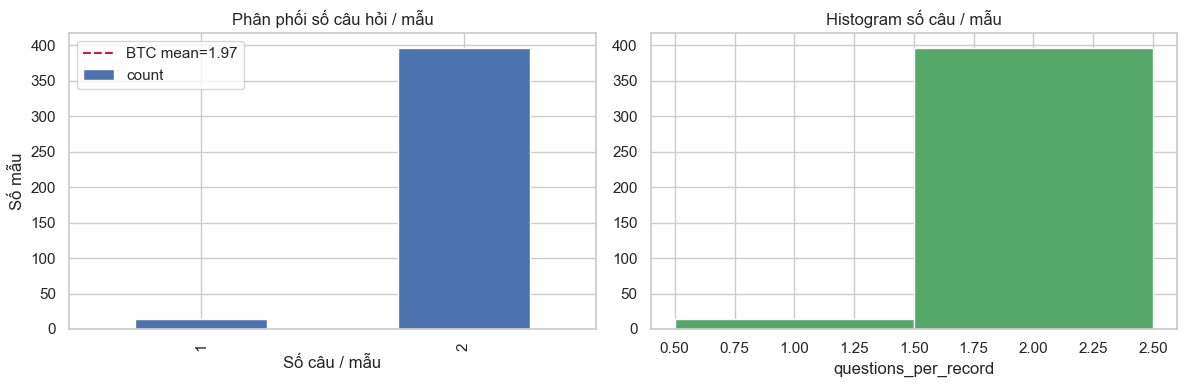

In [278]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc.plot(kind="bar", ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Phân phối số câu hỏi / mẫu")
axes[0].set_xlabel("Số câu / mẫu")
axes[0].set_ylabel("Số mẫu")
axes[0].axvline(BTC["q_per_record"], color="crimson", ls="--", label=f"BTC mean={BTC['q_per_record']}")
axes[0].legend()

axes[1].hist(qpc, bins=range(1, int(qpc.max()) + 2), color="#55A868", edgecolor="white", align="left")
axes[1].set_title("Histogram số câu / mẫu")
axes[1].set_xlabel("questions_per_record")

plt.tight_layout()
plt.savefig(FIG_DIR / "Q_questions_per_record.png", dpi=120, bbox_inches="tight")
plt.show()


In [279]:
# In các mẫu chỉ có 1 câu hỏi
for i in range(len(df_rec)):
    if df_rec['questions_per_record'].iloc[i] == 1:
        # in full record dạng JSON
        print(f"Mẫu {i} có 1 câu hỏi")
        sample = records[i]
        print(json.dumps(sample, ensure_ascii=False, indent=2))
        print("-" * 60)
        print("\n\n")


Mẫu 28 có 1 câu hỏi
{
  "idx": [
    [
      1,
      2,
      3,
      4,
      5,
      9,
      11,
      13,
      16
    ]
  ],
  "premises-FOL": [
    "ForAll(a, (training(a) ∧ simulations(a)) → clearance(a))",
    "ForAll(a, (clearance(a) ∧ safety_audit(vehicle(a))) → approved(a))",
    "ForAll(a, (approved(a) ∧ trajectory(a)) → departs(a))",
    "ForAll(a, (departs(a) ∧ safe_radiation(Mars)) → landing(a))",
    "ForAll(a, (landing(a) ∧ rover(a)) → samples(a))",
    "ForAll(a, (samples(a) ∧ equipment(a)) → breakthrough(a))",
    "training(Luna) ∨ withdraw(Luna)",
    "¬withdraw(Luna)",
    "simulations(Luna)",
    "safety_audit(vehicle(Luna))",
    "trajectory(Luna)",
    "safe_radiation(Mars)",
    "rover(Luna)",
    "equipment(Luna)",
    "lose_contact(control) → ¬trajectory(Luna)",
    "¬lose_contact(control)",
    "malfunction(rover(Luna)) → ¬samples(Luna)",
    "¬malfunction(rover(Luna))",
    "exceed_radiation(Mars) → ¬landing(Luna)",
    "¬exceed_radiation(Mars)",
    "fa

In [280]:
print("=== mean premise dùng / câu theo số câu trong mẫu ===")
q7 = (
    df_q.groupby(df_rec.loc[df_q["record_id"], "questions_per_record"].values)
    ["n_premises_used"]
    .agg(["mean", "median", "count"])
    .rename_axis("questions_per_record")
)
print(q7)


=== mean premise dùng / câu theo số câu trong mẫu ===
                          mean  median  count
questions_per_record                         
1                     6.357143     4.5     14
2                     2.610831     2.0    794


## 3. Schema & integrity


In [281]:
align_errors = []
empty_errors = []
idx_errors = []

for rid, rec in enumerate(records):
    nq = len(rec["questions"])
    na, ne = len(rec["answers"]), len(rec["explanation"])
    ni = len(normalize_idx(rec["idx"], nq))
    if not (nq == na == ne == ni):
        align_errors.append((rid, nq, na, ne, ni))
    if nq == 0 or len(rec["premises-NL"]) == 0:
        empty_errors.append(rid)
    n_prem = len(rec["premises-NL"])
    for qi, idx_list in enumerate(normalize_idx(rec["idx"], nq)):
        for ix in idx_list:
            if ix < 1 or ix > n_prem:
                idx_errors.append((rid, qi, ix, n_prem))

nl_fol_mismatch = [
    rid for rid, r in enumerate(records)
    if get_fol(r) and len(r["premises-NL"]) != len(get_fol(r))
]
missing_fol_only = missing_fol_ids  # đã in ở cell load

print(f"Lệch len(q,a,exp,idx): {len(align_errors)} record")
print(f"NL≠FOL count: {len(nl_fol_mismatch)} record (có FOL nhưng lệch độ dài)")
print(f"Thiếu hẳn premises-FOL: {len(missing_fol_only)} record {missing_fol_only}")
print(f"List rỗng: {len(empty_errors)} record")
print(f"idx ngoài range: {len(idx_errors)} lỗi")
if idx_errors[:3]:
    print("  Ví dụ:", idx_errors[:3])


def record_to_json_dict(rec: dict) -> dict:
    """Record → JSON đúng format gốc (premises-FOL nếu có)."""
    out = {
        "idx": rec["idx"],
        "premises-NL": rec["premises-NL"],
        "questions": rec["questions"],
        "answers": rec["answers"],
        "explanation": rec["explanation"],
    }
    fol = get_fol(rec)
    if fol:
        out["premises-FOL"] = fol
    return out


SEP_REC = "=" * 72
print(f"\n{SEP_REC}")
print(f"Mẫu NL ≠ FOL — in full JSON ({len(nl_fol_mismatch)} record)")
print(SEP_REC)
for rid in nl_fol_mismatch:
    rec = records[rid]
    print(f"\n[record_id={rid}] NL={len(rec['premises-NL'])} | FOL={len(get_fol(rec))}")
    print(json.dumps(record_to_json_dict(rec), ensure_ascii=False, indent=2))


Lệch len(q,a,exp,idx): 0 record
NL≠FOL count: 11 record (có FOL nhưng lệch độ dài)
Thiếu hẳn premises-FOL: 2 record [23, 53]
List rỗng: 0 record
idx ngoài range: 26 lỗi
  Ví dụ: [(57, 1, 13, 12), (74, 0, 13, 12), (76, 0, 0, 13)]

Mẫu NL ≠ FOL — in full JSON (11 record)

[record_id=34] NL=27 | FOL=25
{
  "idx": [
    [
      1,
      2,
      3,
      4,
      6,
      8,
      12,
      13,
      14,
      20,
      22,
      23,
      24,
      26
    ]
  ],
  "premises-NL": [
    "Students are allowed to change majors if their cumulative GPA is 7.0 or higher.",
    "Students must complete at least 2 semesters in their current major before changing.",
    "Accumulated credits must be at least 50% of the total credits of the current program.",
    "The new major must have a professional similarity of 60% or higher, as determined by the professional council.",
    "If students have taken major-specific courses, these courses must be assessed for knowledge equivalence with the new major.

## 4. Loại câu hỏi


=== Loại câu (loại trừ lẫn nhau) ===
q_type
mcq     359
open    233
yn      216

  [BTC: MCQ=358, Y/N=216, Open=234]


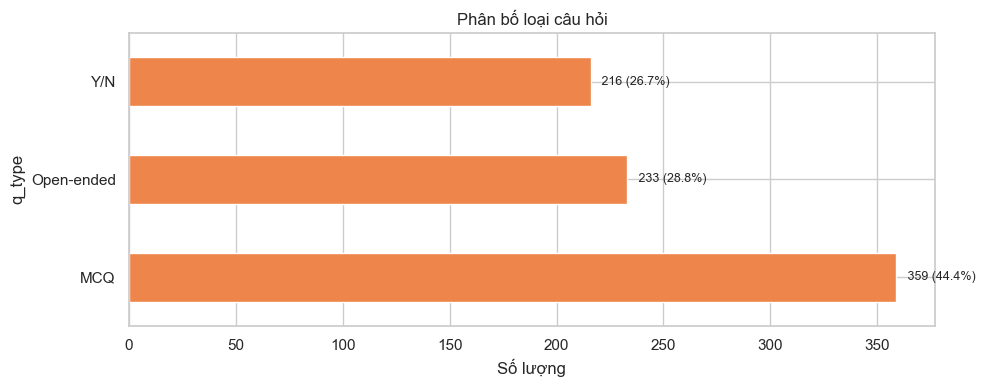

In [282]:
MCQ_PAT = re.compile(
    r"\nA\.|\nB\.|strongest conclusion|fewest premises|Which conclusion|"
    r"which of the following|which is the strongest|which of these conclusions",
    re.I,
)
YN_PAT = re.compile(
    r"Does it follow|according to the premises|is the following statement true|"
    r"is the following true\?|Must .+ follow from|Can .+ be inferred|"
    r"Does .+ follow that|Is it true that",
    re.I,
)


def classify_q_type(text: str) -> str:
    """Phân loại loại trừ lẫn nhau — khớp gần BTC (358 / 216 / 234)."""
    if MCQ_PAT.search(text):
        return "mcq"
    if YN_PAT.search(text):
        return "yn"
    return "open"


df_q["q_type"] = df_q["question"].apply(classify_q_type)
df_q["is_mcq"] = df_q["q_type"] == "mcq"
df_q["is_yn"] = df_q["q_type"] == "yn"
df_q["is_open"] = df_q["q_type"] == "open"

print("=== Loại câu (loại trừ lẫn nhau) ===")
print(df_q["q_type"].value_counts().to_string())
print(f"\n  [BTC: MCQ={BTC['mcq']}, Y/N={BTC['yn_uncertain']}, Open={BTC['open']}]")
q_type_labels = df_q["q_type"].map({"mcq": "MCQ", "yn": "Y/N", "open": "Open-ended"})
plot_count_dist(q_type_labels, "Phân bố loại câu hỏi", "D_question_types.png", top_n=None)


### Phân phối độ dài token theo loại câu (Qwen2.5-7B)

Ngay sau thống kê số câu mỗi loại: đếm **tổng token** khi nạp FOL + NL premises, question, answer, explanation — để chọn `max_seq_length` khi fine-tune.


Đang tải tokenizer Qwen/Qwen2.5-7B-Instruct ...


c:\Users\ASUS\anaconda3\envs\DS310_env_3_10\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


OK.

=== Phân phối token (full context / câu) ===

--- Token / câu — Tất cả (n=808) ---
  mean=471  min=115  max=1614
  P50=446
  P90=753
  P95=862
  % > 2048: 0.0%
  % > 4096: 0.0%
  % > 8192: 0.0%

--- Token / câu — MCQ (n=359) ---
  mean=489  min=150  max=1286
  P50=470
  P90=748
  P95=853
  % > 2048: 0.0%
  % > 4096: 0.0%
  % > 8192: 0.0%



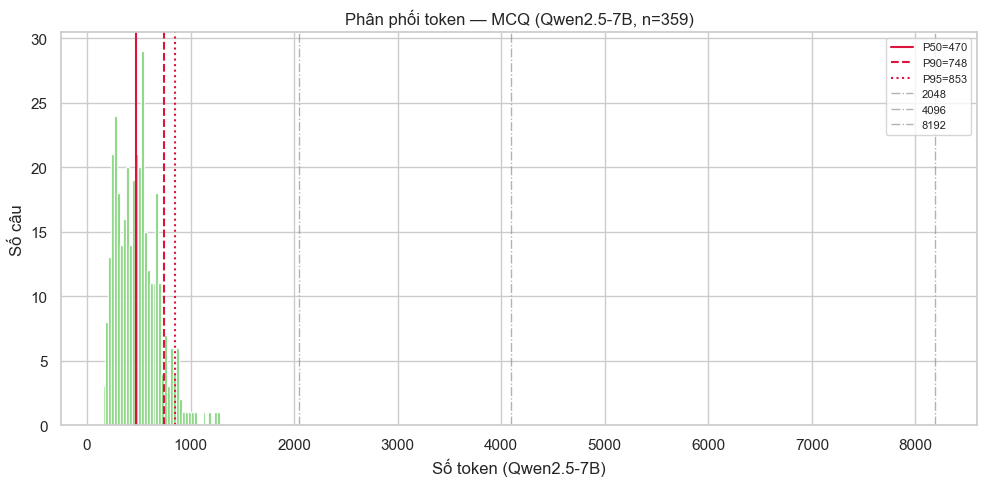

--- Token / câu — Y/N (n=216) ---
  mean=424  min=115  max=1194
  P50=432
  P90=650
  P95=751
  % > 2048: 0.0%
  % > 4096: 0.0%
  % > 8192: 0.0%



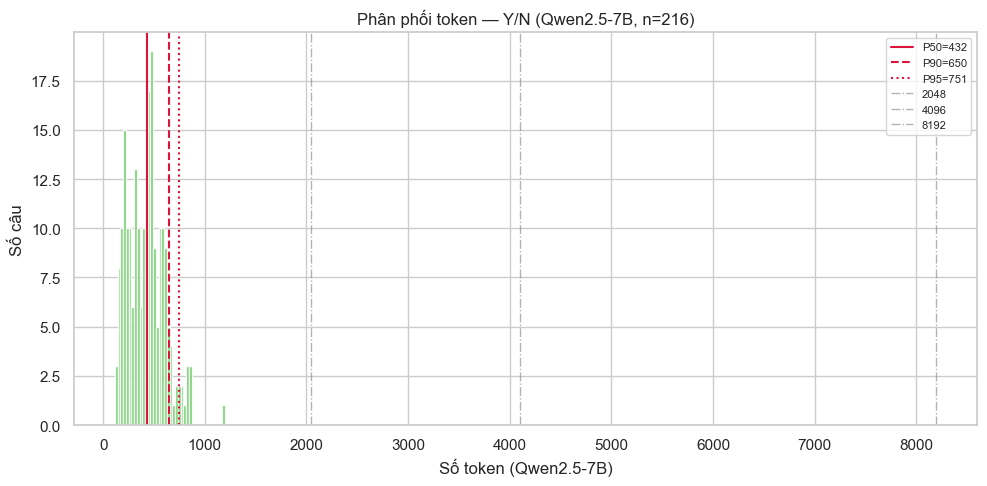

--- Token / câu — Open-ended (n=233) ---
  mean=488  min=158  max=1614
  P50=434
  P90=852
  P95=930
  % > 2048: 0.0%
  % > 4096: 0.0%
  % > 8192: 0.0%



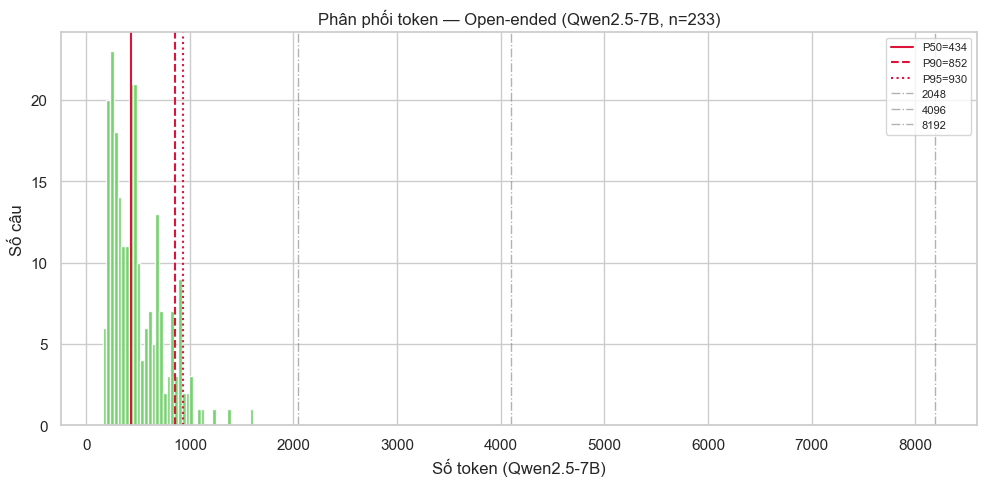

Gợi ý max_seq_length (P95 toàn tập ≈ 862): 1024 hoặc 2048


In [283]:
from transformers import AutoTokenizer

print("Đang tải tokenizer Qwen/Qwen2.5-7B-Instruct ...")
_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct", trust_remote_code=True)
print("OK.\n")


def _build_finetune_text(row) -> str:
    parts = []
    if row["premises_fol"]:
        parts.append("Premises (FOL):\n" + "\n".join(str(x) for x in row["premises_fol"]))
    if row["premises_nl"]:
        parts.append("Premises (NL):\n" + "\n".join(str(x) for x in row["premises_nl"]))
    parts.append("Question:\n" + str(row["question"]))
    if row.get("answer"):
        parts.append("Answer:\n" + str(row["answer"]))
    if row.get("explanation"):
        parts.append("Explanation:\n" + str(row["explanation"]))
    return "\n\n".join(parts)


def _count_tokens(text: str) -> int:
    return len(_tokenizer.encode(text, add_special_tokens=False))


if "n_tokens_total" not in df_q.columns:
    df_q["n_tokens_total"] = df_q.apply(
        lambda r: _count_tokens(_build_finetune_text(r)), axis=1
    )

_THRESH = (2048, 4096, 8192)
_BY_TYPE = [
    ("mcq", "MCQ", "D_token_dist_mcq.png"),
    ("yn", "Y/N", "D_token_dist_yn.png"),
    ("open", "Open-ended", "D_token_dist_open.png"),
]


def _print_token_stats(sub: pd.DataFrame, label: str) -> None:
    s = sub["n_tokens_total"]
    print(f"--- Token / câu — {label} (n={len(sub)}) ---")
    print(f"  mean={s.mean():.0f}  min={s.min()}  max={s.max()}")
    for p in (0.5, 0.9, 0.95):
        print(f"  P{int(p*100)}={s.quantile(p):.0f}")
    for t in _THRESH:
        print(f"  % > {t}: {100 * (s > t).mean():.1f}%")
    print()


def _plot_token_hist(sub: pd.DataFrame, title: str, filename: str) -> None:
    s = sub["n_tokens_total"]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(s, bins=40, color=PALETTE[2], edgecolor="white", alpha=0.9)
    for p, ls in [(0.5, "-"), (0.9, "--"), (0.95, ":")]:
        v = s.quantile(p)
        ax.axvline(v, color="crimson", linestyle=ls, lw=1.5, label=f"P{int(p*100)}={v:.0f}")
    for t in _THRESH:
        ax.axvline(t, color="gray", linestyle="-.", lw=1, alpha=0.6, label=str(t))
    ax.set_xlabel("Số token (Qwen2.5-7B)")
    ax.set_ylabel("Số câu")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
    plt.show()


print("=== Phân phối token (full context / câu) ===\n")
_print_token_stats(df_q, "Tất cả")
for qkey, qlabel, fname in _BY_TYPE:
    sub = df_q[df_q["q_type"] == qkey]
    _print_token_stats(sub, qlabel)
    _plot_token_hist(
        sub,
        f"Phân phối token — {qlabel} (Qwen2.5-7B, n={len(sub)})",
        fname,
    )

p95 = df_q["n_tokens_total"].quantile(0.95)
print(f"Gợi ý max_seq_length (P95 toàn tập ≈ {p95:.0f}): {int(np.ceil(p95 / 256) * 256)} hoặc 2048")



In [284]:
def build_type_samples(q_type: str) -> list[dict]:
    sub = df_q[df_q["q_type"] == q_type]
    return [row_to_record_dict(row) for _, row in sub.iterrows()]


# Biến theo từng loại (format JSON như file gốc)
mcq_samples = build_type_samples("mcq")
yn_samples = build_type_samples("yn")
open_samples = build_type_samples("open")
row_to_open_dict = row_to_record_dict  # alias (open)

df_open = df_q[df_q["q_type"] == "open"].copy()

TYPE_BLOCKS = [
    ("MCQ — Multiple Choice", mcq_samples, BTC["mcq"]),
    ("Y/N — Yes · No · Uncertain", yn_samples, BTC["yn_uncertain"]),
    ("Open-ended", open_samples, BTC["open"]),
]

SEP_MAJOR = "=" * 72
SEP_MINOR = "-" * 60
N_PREVIEW = 10

for title, samples, btc_n in TYPE_BLOCKS:
    print(SEP_MAJOR)
    print(f"  {title}")
    print(f"  Tổng: {len(samples)} mẫu  |  BTC: {btc_n}  |  In {min(N_PREVIEW, len(samples))} sample")
    print(SEP_MAJOR + "\n")

    for i, sample in enumerate(samples[:N_PREVIEW], start=1):
        print(f"[{title}] Sample {i}/{N_PREVIEW}")
        print(json.dumps(sample, ensure_ascii=False, indent=2))
        print(SEP_MINOR + "\n")

    print("\n")


  MCQ — Multiple Choice
  Tổng: 359 mẫu  |  BTC: 358  |  In 10 sample

[MCQ — Multiple Choice] Sample 1/10
{
  "idx": [
    [
      1
    ]
  ],
  "premises-FOL": [
    "∀x (WT(x) → O(x))",
    "∀x (¬PEP8(x) → ¬WT(x))",
    "∀x (EM(x))",
    "∀x (WT(x))",
    "∀x (PEP8(x) → EM(x))",
    "∀x (WT(x) → PEP8(x))",
    "∀x (WS(x) → O(x))",
    "∀x (EM(x) → WT(x))",
    "�forall(x, O(x) -> CR(x))",
    "∀x (WS(x))",
    "∀x (CR(x))",
    "∃x (BP(x))",
    "∃x (O(x))",
    "∀x (¬WS(x) → ¬PEP8(x))"
  ],
  "premises-NL": [
    "If a Python code is well-tested, then the project is optimized.",
    "If a Python code does not follow PEP 8 standards, then it is not well-tested.",
    "All Python projects are easy to maintain.",
    "All Python code is well-tested.",
    "If a Python code follows PEP 8 standards, then it is easy to maintain.",
    "If a Python code is well-tested, then it follows PEP 8 standards.",
    "If a Python project is well-structured, then it is optimized.",
    "If a Python

## 5. Reasoning challenges


In [285]:
print("=== Premise / mẫu & / câu ===")
print(df_rec["n_premises_nl"].describe())
print(f"Mean NL/mẫu: {df_rec['n_premises_nl'].mean():.2f}  [BTC: {BTC['nl_per_record']}]")
print(f"\nPremise dùng / câu:")
print(df_q["n_premises_used"].describe())
print(f"Tỷ lệ dùng/tổng (mean): {df_q['premise_use_ratio'].mean():.2%}")

def count_premise_refs(text: str) -> int:
    return len(re.findall(r"Premise\s+(\d+)", text, re.I))


def count_steps(text: str) -> int:
    n = len(re.findall(r"Premise\s+\d+", text, re.I))
    n += len(re.findall(r"\bstep\s+\d+", text, re.I))
    n += text.count("→")
    return max(n, 1) if text.strip() else 0


df_q["n_cited_in_exp"] = df_q["explanation"].apply(count_premise_refs)
df_q["n_reasoning_steps"] = df_q["explanation"].apply(count_steps)

print(f"\nBước suy luận trong explanation (heuristic) — mean: {df_q['n_reasoning_steps'].mean():.2f}")
print("\nPremise dùng / câu — median theo loại câu (MCQ vs không MCQ):")
print(df_q.groupby("is_mcq")["n_premises_used"].median())


=== Premise / mẫu & / câu ===
count    411.000000
mean      10.798054
std        5.929718
min        3.000000
25%        7.000000
50%       10.000000
75%       14.000000
max       36.000000
Name: n_premises_nl, dtype: float64
Mean NL/mẫu: 10.80  [BTC: 10.8]

Premise dùng / câu:
count    808.000000
mean       2.675743
std        1.651496
min        0.000000
25%        2.000000
50%        2.000000
75%        3.000000
max       20.000000
Name: n_premises_used, dtype: float64
Tỷ lệ dùng/tổng (mean): 32.75%

Bước suy luận trong explanation (heuristic) — mean: 3.34

Premise dùng / câu — median theo loại câu (MCQ vs không MCQ):
is_mcq
False    2.0
True     3.0
Name: n_premises_used, dtype: float64


=== Negation & exceptions ===
premise NL if-then: 42.2%
premise NL phủ định: 22.4%
premise FOL ¬/not: 27.3%
câu hỏi phủ định: 36.3%
mẫu có exception: 2.7%


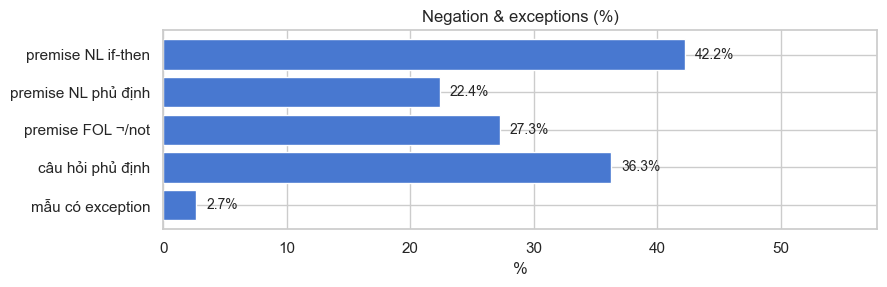

In [286]:
NEG_NL = re.compile(r"\bnot\b|\bnever\b|\bwithout\b|\bno\s+", re.I)
NEG_FOL = re.compile(r"¬|\bnot\b|ForAll.*Not|\(not\s", re.I)
EXC = re.compile(r"unless|except|only if|provided that", re.I)
IF_THEN = re.compile(r"if\b.*\bthen\b", re.I)
NUM_Q = re.compile(r"\d|more than|at least|GPA|credit|percent|%", re.I)

all_nl = [p for r in records for p in r["premises-NL"]]
all_fol = [p for r in records for p in get_fol(r)]

print("=== Negation & exceptions ===")
has_exc = [any(EXC.search(p) for p in r["premises-NL"]) for r in records]
a2_metrics = {
    "premise NL if-then": 100 * np.mean([bool(IF_THEN.search(p)) for p in all_nl]),
    "premise NL phủ định": 100 * np.mean([bool(NEG_NL.search(p)) for p in all_nl]),
    "premise FOL ¬/not": 100 * np.mean([bool(NEG_FOL.search(p)) for p in all_fol]),
    "câu hỏi phủ định": 100 * df_q["question"].str.contains(NEG_NL).mean(),
    "mẫu có exception": 100 * np.mean(has_exc),
}
for k, v in a2_metrics.items():
    print(f"{k}: {v:.1f}%")
plot_pct_bars(a2_metrics, "Negation & exceptions (%)", "A2_negation_exceptions.png")


=== Phân bố nhãn ===
answer_norm
Unknown        315
No             307
Yes            107
MCQ_A           51
MCQ_B           15
MCQ_C            7
MCQ_D            5
other_short      1
Name: count, dtype: int64

Tỷ lệ Unknown: 39.0%


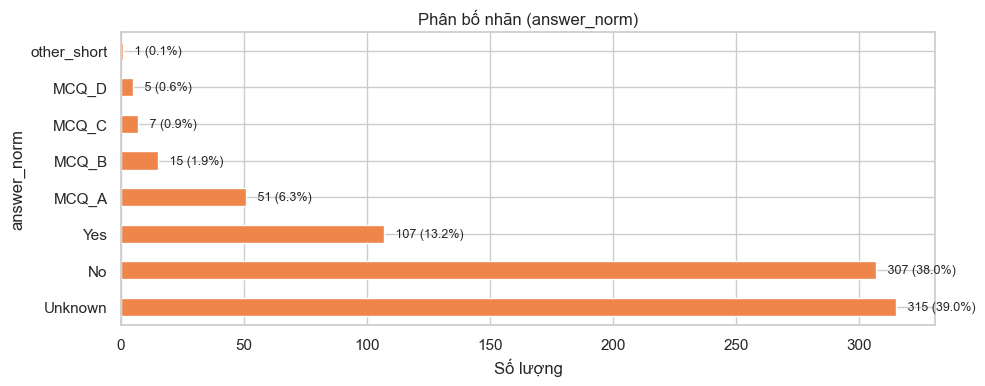

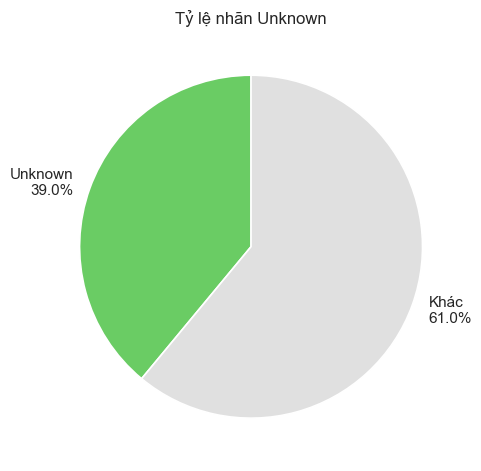


len(idx) theo nhãn (median):
answer_norm
No             2.0
Unknown        2.0
Yes            2.0
MCQ_A          3.0
MCQ_B          3.0
MCQ_D          3.0
MCQ_C          4.0
other_short    4.0
Name: n_premises_used, dtype: float64

Unknown theo loại câu:
is_mcq       False  True  All
answer_norm                  
False          416    77  493
True            33   282  315
All            449   359  808


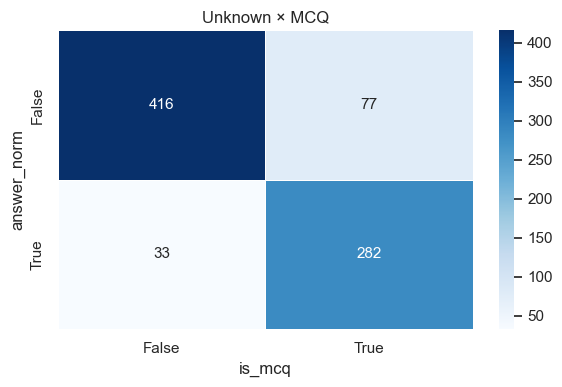

In [287]:
def norm_answer(a: str) -> str:
    a = str(a).strip()
    if a in {"Yes", "No", "Unknown", "Uncertain"}:
        return a
    if re.fullmatch(r"[A-D]", a):
        return f"MCQ_{a}"
    if len(a) <= 20:
        return "other_short"
    return "other_long"


df_q["answer_norm"] = df_q["answer"].apply(norm_answer)

print("=== Phân bố nhãn ===")
print(df_q["answer_norm"].value_counts())
pct_unknown = 100 * (df_q["answer_norm"] == "Unknown").mean()
print(f"\nTỷ lệ Unknown: {pct_unknown:.1f}%")
plot_count_dist(df_q["answer_norm"], "Phân bố nhãn (answer_norm)", "A3_answer_norm.png")
plot_binary_pie(pct_unknown, "Tỷ lệ nhãn Unknown", "A3_unknown_pie.png", yes_label="Unknown", no_label="Khác")

print("\nlen(idx) theo nhãn (median):")
print(df_q.groupby("answer_norm")["n_premises_used"].median().sort_values())

print("\nUnknown theo loại câu:")
unk = df_q["answer_norm"] == "Unknown"
ct_unk_mcq = pd.crosstab(unk, df_q["is_mcq"], margins=True)
print(ct_unk_mcq)
plot_heatmap_ct(ct_unk_mcq.iloc[:-1, :-1], "Unknown × MCQ", "A3_unknown_vs_mcq.png")


=== Số học trong NL ===
câu có số/so sánh: 20.5%
mẫu premise có ngưỡng: 64.2%


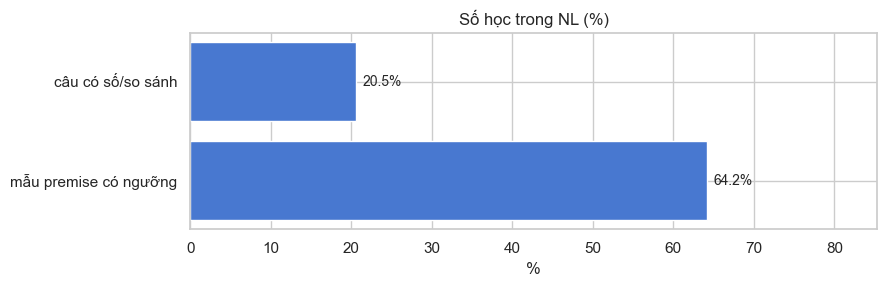


Unknown × có số:
has_numeric  False  True 
answer_norm              
False          395     98
True           247     68


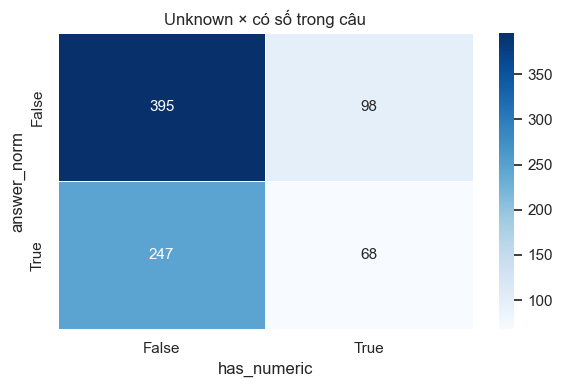

In [288]:
df_q["has_numeric"] = df_q["question"].str.contains(NUM_Q, regex=True)
rec_num_prem = [any(NUM_Q.search(p) for p in r["premises-NL"]) for r in records]

print("=== Số học trong NL ===")
a4_metrics = {
    "câu có số/so sánh": 100 * df_q["has_numeric"].mean(),
    "mẫu premise có ngưỡng": 100 * np.mean(rec_num_prem),
}
for k, v in a4_metrics.items():
    print(f"{k}: {v:.1f}%")
plot_pct_bars(a4_metrics, "Số học trong NL (%)", "A4_numeric.png")
print("\nUnknown × có số:")
ct_unk_num = pd.crosstab(df_q["answer_norm"] == "Unknown", df_q["has_numeric"])
print(ct_unk_num)
plot_heatmap_ct(ct_unk_num, "Unknown × có số trong câu", "A4_unknown_numeric.png")


## 6. Explanation & FOL challenges


=== FOL ===
1 % mẫu có FOL: 99.5%  [BTC: 99%]
2 Notation: ∀ unicode=1604, ForAll(...)=1625
3 FOL lỗi/encoding: 1631 premise
  → �forall(x, O(x) -> CR(x))...
  → ForAll(x, (completed_core_curriculum(x) ∧ passed_science_assessment(x)) → qualif...
4 NL==FOL len: 96.8% mẫu khớp
5 universal=3226, existential=751, total premises=4439


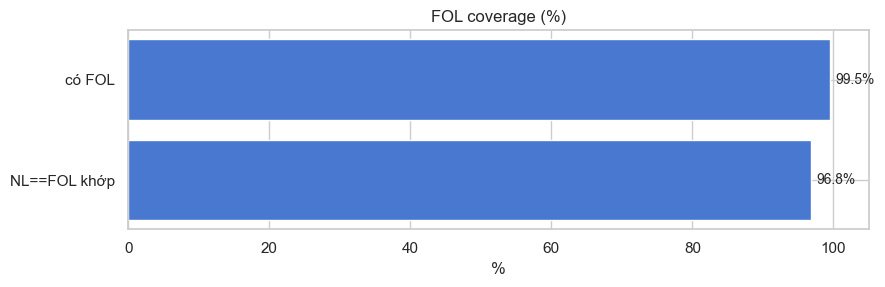

C:\Users\ASUS\AppData\Local\Temp\ipykernel_32440\331151581.py:57: UserWarning: Glyph 8704 (\N{FOR ALL}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_32440\331151581.py:58: UserWarning: Glyph 8704 (\N{FOR ALL}) missing from current font.
  plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")
c:\Users\ASUS\anaconda3\envs\DS310_env_3_10\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8704 (\N{FOR ALL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


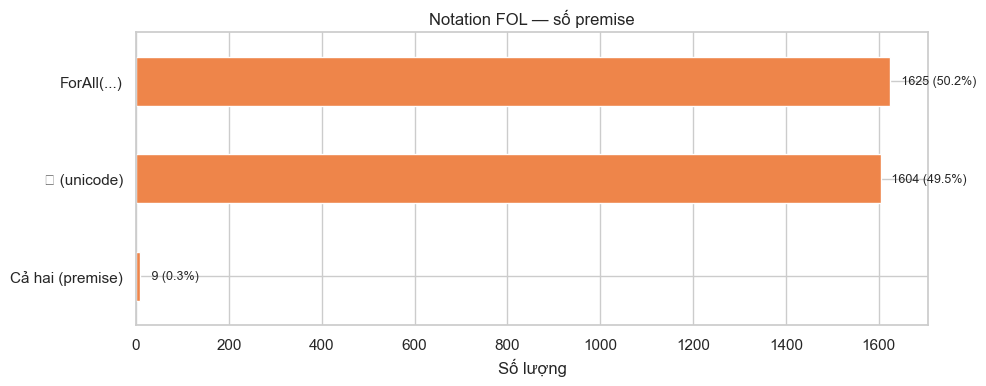

In [289]:
UNIV1 = re.compile(r"∀|ForAll|forall", re.I)
EXIST = re.compile(r"∃|Exists|exists", re.I)
FOL_BROKEN = re.compile(r"\ufffd|\bforall\s*\(", re.I)

fol_univ = sum(1 for p in all_fol if UNIV1.search(p))
fol_exist = sum(1 for p in all_fol if EXIST.search(p))
fol_broken = [p for p in all_fol if FOL_BROKEN.search(p)]
notation_forall_unicode = sum(1 for p in all_fol if "∀" in p)
notation_forall_word = sum(1 for p in all_fol if re.search(r"ForAll\s*\(", p))

print("=== FOL ===")
pct_has_fol = 100 * df_rec["has_fol"].mean()
pct_nl_fol_match = 100 * df_rec["nl_fol_match"].mean()
print(f"1 % mẫu có FOL: {pct_has_fol:.1f}%  [BTC: {BTC['fol_pct']}%]")
print(f"2 Notation: ∀ unicode={notation_forall_unicode}, ForAll(...)={notation_forall_word}")
print(f"3 FOL lỗi/encoding: {len(fol_broken)} premise")
if fol_broken[:2]:
    for p in fol_broken[:2]:
        print(f"  → {p[:80]}...")
print(f"4 NL==FOL len: {pct_nl_fol_match:.1f}% mẫu khớp")
print(f"5 universal={fol_univ}, existential={fol_exist}, total premises={len(all_fol)}")
plot_pct_bars(
    {"có FOL": pct_has_fol, "NL==FOL khớp": pct_nl_fol_match},
    "FOL coverage (%)",
    "B1_fol_coverage.png",
)
fol_notation_counts = pd.Series(
    {
        "∀ (unicode)": notation_forall_unicode,
        "ForAll(...)": notation_forall_word,
        "Cả hai (premise)": sum(
            1 for p in all_fol if "∀" in p and re.search(r"ForAll\s*\(", p)
        ),
    }
)
plot_count_dist(
    fol_notation_counts,
    "Notation FOL — số premise",
    "B1_fol_notation.png",
    top_n=None,
    horizontal=True,
    preaggregated=True,
)


In [290]:
df_q["exp_words"] = df_q["explanation"].str.split().str.len()
df_q["q_words"] = df_q["question"].str.split().str.len()

print("=== Độ dài explanation (từ) ===")
print(df_q["exp_words"].describe())
print(f"P50={df_q['exp_words'].median():.0f}, P90={df_q['exp_words'].quantile(0.9):.0f}")

print("\nTheo loại câu (median từ):")
for col, label in [("is_mcq", "MCQ"), ("is_yn", "Y/N"), ("is_open", "Open")]:
    sub = df_q.loc[df_q[col], "exp_words"]
    print(f"  {label}: median={sub.median():.0f}, n={len(sub)}")


=== Độ dài explanation (từ) ===
count    808.000000
mean      56.007426
std       37.618873
min       13.000000
25%       30.000000
50%       40.000000
75%       73.250000
max      220.000000
Name: exp_words, dtype: float64
P50=40, P90=112

Theo loại câu (median từ):
  MCQ: median=47, n=359
  Y/N: median=55, n=216
  Open: median=33, n=233


=== Trích dẫn premise ===
2 mean premise cite trong explanation: 2.87
Overlap cite ∩ idx: 89.9%
Cite nằm trong idx: 91.2%
Under-citation: 10.3%
Over-citation: 8.8%


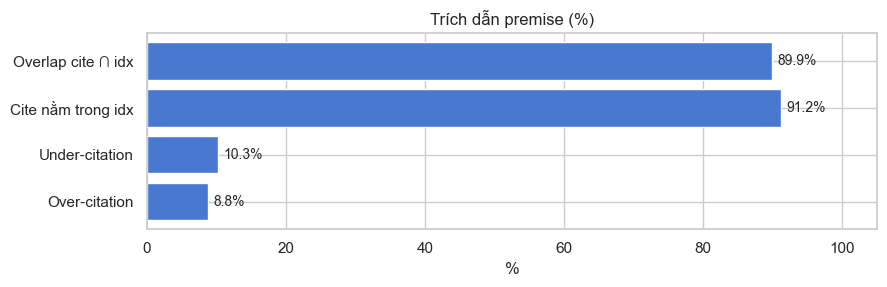

In [291]:
def cited_indices(text: str) -> set[int]:
    return {int(x) for x in re.findall(r"Premise\s+(\d+)", text, re.I)}


def idx_set(lst) -> set[int]:
    return set(lst)


df_q["cited_set"] = df_q["explanation"].apply(cited_indices)
df_q["idx_set"] = df_q["idx_used"].apply(idx_set)
df_q["cite_overlap"] = df_q.apply(
    lambda r: len(r["cited_set"] & r["idx_set"]) / len(r["idx_set"]) if r["idx_set"] else np.nan,
    axis=1,
)
df_q["cite_subset"] = df_q.apply(lambda r: r["cited_set"] <= r["idx_set"], axis=1)
df_q["under_cite"] = df_q.apply(
    lambda r: len(r["cited_set"]) < len(r["idx_set"]) if r["idx_set"] else False, axis=1
)
df_q["over_cite"] = df_q.apply(
    lambda r: len(r["cited_set"]) > len(r["idx_set"]) or bool(r["cited_set"] - r["idx_set"]),
    axis=1,
)

print("=== Trích dẫn premise ===")
print(f"2 mean premise cite trong explanation: {df_q['n_cited_in_exp'].mean():.2f}")
b4_metrics = {
    "Overlap cite ∩ idx": 100 * df_q["cite_overlap"].mean(),
    "Cite nằm trong idx": 100 * df_q["cite_subset"].mean(),
    "Under-citation": 100 * df_q["under_cite"].mean(),
    "Over-citation": 100 * df_q["over_cite"].mean(),
}
for k, v in b4_metrics.items():
    print(f"{k}: {v:.1f}%")
plot_pct_bars(b4_metrics, "Trích dẫn premise (%)", "B4_premise_citation.png")


4 Outlier answer (len>20): 0 câu
1 MCQ answer trong explanation: 57.7% (45/78)
2 Y/N heuristic khớp explanation: 35.7%
Unknown + pattern abstain trong exp: 11.7%


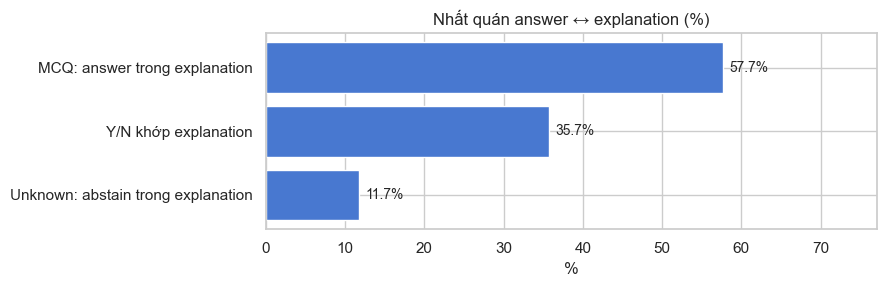

In [292]:
df_q["ans_len"] = df_q["answer"].str.len()
outlier_ans = df_q[df_q["ans_len"] > 20]
print(f"4 Outlier answer (len>20): {len(outlier_ans)} câu")

mcq = df_q["answer_norm"].str.startswith("MCQ_")
mcq_ok = df_q.loc[mcq].apply(
    lambda r: r["answer"].strip() in r["explanation"], axis=1
)
pct_mcq_ok = 100 * mcq_ok.mean() if mcq.sum() else 0.0
print(f"1 MCQ answer trong explanation: {pct_mcq_ok:.1f}% ({mcq_ok.sum()}/{mcq.sum()})")

yn = df_q["answer_norm"].isin(["Yes", "No"])
def yn_match(r):
    exp = r["explanation"].lower()
    if r["answer"] == "Yes":
        return "yes" in exp[-200:] or "holds" in exp[-200:] or "true" in exp[-200:]
    return "no" in exp[-200:] or "false" in exp[-200:] or "does not" in exp[-200:]

yn_ok = df_q.loc[yn].apply(yn_match, axis=1)
pct_yn_ok = 100 * yn_ok.mean() if yn.sum() else 0.0
print(f"2 Y/N heuristic khớp explanation: {pct_yn_ok:.1f}%")

unk = df_q["answer_norm"] == "Unknown"
unk_pat = re.compile(r"cannot|uncertain|unknown|not determine|insufficient", re.I)
unk_ok = df_q.loc[unk, "explanation"].str.contains(unk_pat)
pct_unk_ok = 100 * unk_ok.mean() if unk.sum() else 0.0
print(f"Unknown + pattern abstain trong exp: {pct_unk_ok:.1f}%")
b3_metrics = {
    "MCQ: answer trong explanation": pct_mcq_ok,
    "Y/N khớp explanation": pct_yn_ok,
    "Unknown: abstain trong explanation": pct_unk_ok,
}
plot_pct_bars(b3_metrics, "Nhất quán answer ↔ explanation (%)", "B3_answer_explanation.png")


## 7. Check Duplicate


In [296]:
from collections import defaultdict

dup_q = df_q["question"].duplicated().sum()
prem_key = [tuple(r["premises-NL"]) for r in records]
dup_prem = len(prem_key) - len(set(prem_key))
print(f"Câu hỏi trùng exact: {dup_q}")
print(f"Bộ premise-NL trùng: {dup_prem} mẫu (record thừa)")


def _record_json(rec: dict) -> dict:
    out = {
        "idx": rec["idx"],
        "premises-NL": rec["premises-NL"],
        "questions": rec["questions"],
        "answers": rec["answers"],
        "explanation": rec["explanation"],
    }
    fol = get_fol(rec)
    if fol:
        out["premises-FOL"] = fol
    return out


SEP_DUP = "=" * 72

dup_q_mask = df_q["question"].duplicated(keep=False)
if dup_q_mask.any():
    print(f"\n{SEP_DUP}")
    print("Mẫu câu hỏi trùng (exact) — full JSON record")
    print(SEP_DUP)
    for qtext, sub in df_q.loc[dup_q_mask].groupby("question", sort=False):
        locs = list(sub[["record_id", "q_idx"]].itertuples(index=False, name=None))
        print(f"\n--- {len(sub)} câu trùng @ {locs} ---")
        preview = qtext if len(qtext) <= 120 else qtext[:120] + "..."
        print(f"Question: {preview}")
        for rid in dict.fromkeys(sub["record_id"]):
            print(f"\n[record_id={rid}]")
            print(json.dumps(_record_json(records[rid]), ensure_ascii=False, indent=2))
else:
    print("\n(Không có câu hỏi trùng exact)")

prem_groups: dict[tuple, list[int]] = defaultdict(list)
for rid, key in enumerate(prem_key):
    prem_groups[key].append(rid)
dup_prem_groups = [rids for rids in prem_groups.values() if len(rids) > 1]
if dup_prem_groups:
    print(f"\n{SEP_DUP}")
    print(f"Mẫu premises-NL trùng — {len(dup_prem_groups)} nhóm — full JSON")
    print(SEP_DUP)
    for gi, rids in enumerate(dup_prem_groups, start=1):
        n_nl = len(records[rids[0]]["premises-NL"])
        print(f"\n--- Nhóm {gi}: record_id={rids} | {n_nl} premise-NL ---")
        for rid in rids:
            print(f"\n[record_id={rid}]")
            print(json.dumps(_record_json(records[rid]), ensure_ascii=False, indent=2))
else:
    print("\n(Không có bộ premises-NL trùng)")


Câu hỏi trùng exact: 20
Bộ premise-NL trùng: 10 mẫu (record thừa)

Mẫu câu hỏi trùng (exact) — full JSON record

--- 2 câu trùng @ [(1, 1), (2, 1)] ---
Question: Does Sophia qualify for the university scholarship, according to the premises?

[record_id=1]
{
  "idx": [
    [
      1,
      2,
      4,
      5,
      7,
      8,
      9,
      10,
      11
    ],
    [
      1,
      2,
      4,
      5,
      7,
      8,
      9,
      10,
      11
    ]
  ],
  "premises-NL": [
    "Students who have completed the core curriculum and passed the science assessment are qualified for advanced courses.",
    "Students who are qualified for advanced courses and have completed research methodology are eligible for the international program.",
    "Students who have passed the language proficiency exam are eligible for the international program.",
    "Students who are eligible for the international program and have completed a capstone project are awarded an honors diploma.",
    "Students wh

## 8. Visualizations tổng hợp


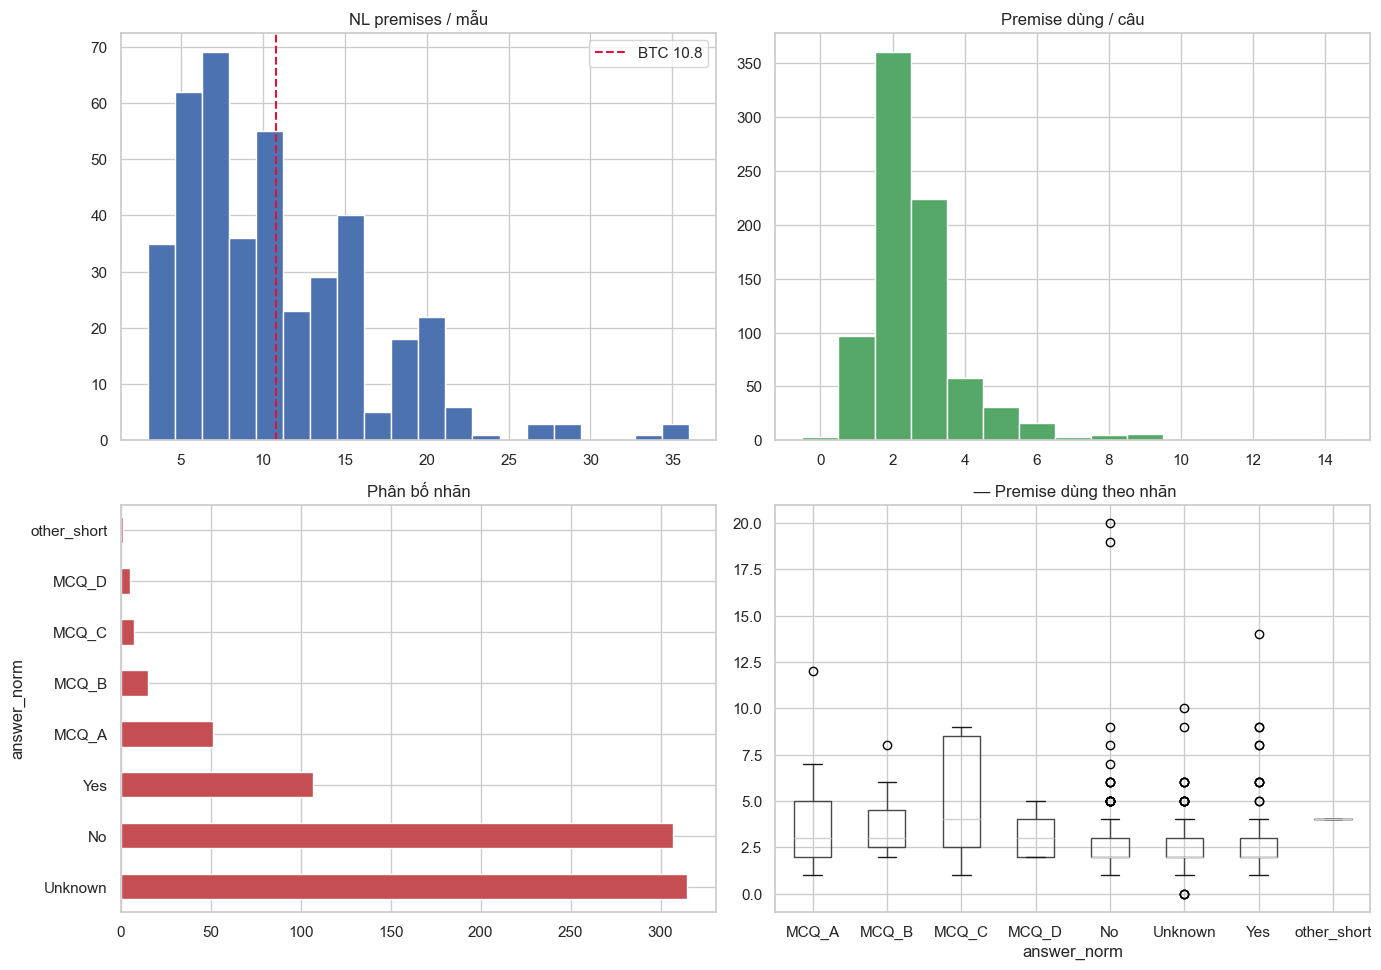

In [294]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_rec["n_premises_nl"].hist(ax=axes[0, 0], bins=20, color="#4C72B0", edgecolor="white")
axes[0, 0].axvline(BTC["nl_per_record"], color="crimson", ls="--", label=f"BTC {BTC['nl_per_record']}")
axes[0, 0].set_title("NL premises / mẫu")
axes[0, 0].legend()

df_q["n_premises_used"].hist(ax=axes[0, 1], bins=range(0, 16), color="#55A868", edgecolor="white", align="left")
axes[0, 1].set_title("Premise dùng / câu")

df_q["answer_norm"].value_counts().plot(kind="barh", ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Phân bố nhãn")

df_q.boxplot(column="n_premises_used", by="answer_norm", ax=axes[1, 1])
axes[1, 1].set_title(" — Premise dùng theo nhãn")
plt.suptitle("")

plt.tight_layout()
plt.savefig(FIG_DIR / "EDA_summary_Logic.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Tóm tắt định lượng (điền tự động)


In [295]:
summary = f"""
=== TÓM TẮT EDA — Logic_Based_Educational_Queries ===

• Câu / mẫu: mean={qpc.mean():.2f}, P50={qpc.median():.0f}, max={qpc.max()} ({pct_1:.1f}% mẫu 1 câu, {pct_2:.1f}% 2 câu)
• Tổng câu: {len(df_q)} (BTC {BTC['n_questions']})
• Premise NL / mẫu: mean={df_rec['n_premises_nl'].mean():.2f} (BTC ~{BTC['nl_per_record']})
• Premise dùng / câu: P50={df_q['n_premises_used'].median():.0f}, P90={df_q['n_premises_used'].quantile(0.9):.0f}
• MCQ: premise dùng P50={df_q.loc[df_q['is_mcq'], 'n_premises_used'].median():.0f}
• Y/N:  premise dùng P50={df_q.loc[df_q['is_yn'], 'n_premises_used'].median():.0f}
• % Unknown: {100*(df_q['answer_norm']=='Unknown').mean():.1f}%
• % explanation cite ⊆ idx: {df_q['cite_subset'].mean():.1%}
• % mẫu có FOL: {df_rec['has_fol'].mean():.1%}
• Loại câu (chồng): MCQ={df_q['is_mcq'].sum()}, Y/N={df_q['is_yn'].sum()}, Open={df_q['is_open'].sum()}
"""
print(summary)

with open(OUT_DIR / "eda_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary)

export_cols = [
    "record_id", "q_idx", "n_premises_nl", "n_premises_used", "premise_use_ratio",
    "question", "answer", "answer_norm", "is_mcq", "is_yn", "is_open",
    "exp_words", "n_cited_in_exp", "cite_subset", "has_numeric",
]
df_q[export_cols].to_csv(OUT_DIR / "logic_flat.csv", index=False)
print(f"Đã lưu: {OUT_DIR / 'logic_flat.csv'}, {OUT_DIR / 'eda_summary.txt'}")
print(f"Figures: {FIG_DIR}")



=== TÓM TẮT EDA — Logic_Based_Educational_Queries ===

• Câu / mẫu: mean=1.97, P50=2, max=2 (3.4% mẫu 1 câu, 96.6% 2 câu)
• Tổng câu: 808 (BTC 808)
• Premise NL / mẫu: mean=10.80 (BTC ~10.8)
• Premise dùng / câu: P50=2, P90=4
• MCQ: premise dùng P50=3
• Y/N:  premise dùng P50=2
• % Unknown: 39.0%
• % explanation cite ⊆ idx: 91.2%
• % mẫu có FOL: 99.5%
• Loại câu (chồng): MCQ=359, Y/N=216, Open=233

Đã lưu: E:\exact_2026\EDA_Logic_Based_Educational_Queries\output\logic_flat.csv, E:\exact_2026\EDA_Logic_Based_Educational_Queries\output\eda_summary.txt
Figures: E:\exact_2026\EDA_Logic_Based_Educational_Queries\figures
